## **PART 1**

### **Shira T - 8077**

**TOP 1000 Steam Games (2024-2026)**

---
### AI uses and prompt:

* During the project, AI tools were used to support the learning process, including understanding machine learning concepts, implementing KNN, and performing feature engineering.
The AI assisted in suggesting ideas, improving code structure, and debugging errors when needed.
The final design choices, feature selection, and interpretation of results were carried out independently.
---

### Explanation of the learning problem & dataset

* This project focuses on predicting the success of video games on the Steam platform using machine learning techniques. The dataset consists of the top 1000 most popular Steam games and includes features such as price, release date, genre, user review score, number of reviews, and peak number of players. **The goal** of the project is to classify whether a game is successful or not based on these features. To define success, a new binary label was created using the estimated number of owners: games with a number of owners above the median value are considered successful (label 1), while the others are considered unsuccessful (label 0). The model is trained on the available features (excluding the owners data) and evaluated based on its ability to correctly predict the success label.
---.

In [94]:
import pandas as pd

#קריאת הדאטה
df = pd.read_csv(r"C:\Users\Shira\OneDrive\Desktop\steam_games_2026.csv")

#הצגת 5 שורות ראשונות
print(df.head())

# חישוב median - for owners
median_value = df["Estimated_Owners"].median()
print("Median:", median_value)

     AppID                   Name Release_Date Primary_Genre  \
0      730       Counter-Strike 2   2012-08-21        Action   
1  2868840       Slay the Spire 2   2026-03-05         Indie   
2  3321460         Crimson Desert   2026-03-19        Action   
3  3065800               Marathon   2026-03-05        Action   
4  3764200  Resident Evil Requiem   2026-02-26        Action   

                                            All_Tags  Price_USD  Discount_Pct  \
0  FPS;Shooter;Multiplayer;Competitive;Action;Tea...       0.00             0   
1  Strategy;Roguelike;Card Game;Deckbuilding;Co-o...      24.99             0   
2  Action;Open World;Singleplayer;Adventure;Comba...      69.99             0   
3  Extraction Shooter;PvP;Multiplayer;Sci-fi;Shoo...      39.99             0   
4  Survival Horror;Zombies;Horror;Third-Person Sh...      69.99             0   

   Review_Score_Pct  Total_Reviews Steam_Deck_Status  Estimated_Owners  \
0                83        4980365           Unknown  

**Train set:**

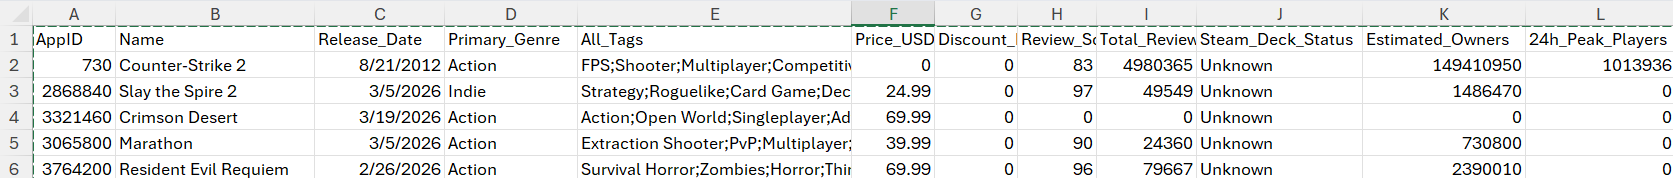

**Test set:**

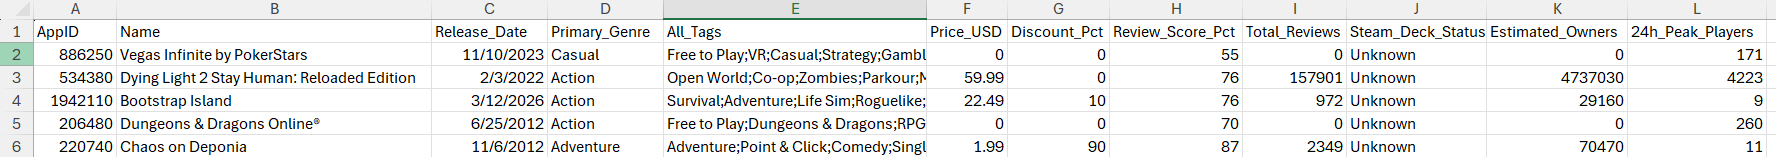


## **PART 2**

In [8]:
# FEATURE ENGINEERING
#התפלגות שנים +הגדרת חדש/בינוני/ישן

import pandas as pd

df = pd.read_csv(r"C:\Users\Shira\OneDrive\Desktop\steam_games_2026.csv")

# המרה לתאריך
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce")

#חילוץ שנה
df["release_year"] = df["Release_Date"].dt.year

#בדיקת התפלגות
print(df["release_year"].describe())

# חישוב גיל המשחק
df["game_age"] = 2026 - df["release_year"]

# הגדרת קטגוריות
def age_category(age):
    if age <= 2:
        return "new"
    elif age <= 6:
        return "medium"
    else:
        return "old"
        
df["age_category"] = df["game_age"].apply(age_category)

# בדיקה
print(df[["release_year", "game_age", "age_category"]].head())


count     998.000000
mean     2021.313627
std         4.340663
min      2006.000000
25%      2019.000000
50%      2023.000000
75%      2025.000000
max      2026.000000
Name: release_year, dtype: float64
   release_year  game_age age_category
0        2012.0      14.0          old
1        2026.0       0.0          new
2        2026.0       0.0          new
3        2026.0       0.0          new
4        2026.0       0.0          new


In [9]:
# ז'אנרים – כן, לגמרי אפשר ידני

# רשימת ז'אנרים
top_genres = ["Action", "RPG", "Adventure", "Strategy", "Simulation"]

for genre in top_genres:
    df[f"is_{genre.lower()}"] = df["All_Tags"].str.contains(genre, na=False).astype(int)

print(df[[f"is_{g.lower()}" for g in top_genres]].head())

   is_action  is_rpg  is_adventure  is_strategy  is_simulation
0          1       0             0            0              0
1          0       0             0            1              0
2          1       0             1            0              0
3          1       0             0            0              0
4          1       0             1            0              0


In [10]:
# מחיר + הנחה

# מחיר לקטגוריות
def price_category(price):
    if price == 0:
        return "free"
    elif price <= 10:
        return "cheap"
    elif price <= 40:
        return "mid"
    else:
        return "expensive"

df["price_category"] = df["Price_USD"].apply(price_category)

# הנחה(כן/לא)
df["has_discount"] = (df["Discount_Pct"] > 0).astype(int)

print(df[["Price_USD", "price_category", "Discount_Pct", "has_discount"]].head())

   Price_USD price_category  Discount_Pct  has_discount
0       0.00           free             0             0
1      24.99            mid             0             0
2      69.99      expensive             0             0
3      39.99            mid             0             0
4      69.99      expensive             0             0


In [11]:
# ציון (Review Score)

# לבדוק התפלגות
print(df["Review_Score_Pct"].describe())

# קטגוריות
def score_category(score):
    if score < 50:
        return "low"
    elif score < 80:
        return "medium"
    else:
        return "high"

df["score_category"] = df["Review_Score_Pct"].apply(score_category)

print(df[["Review_Score_Pct", "score_category"]].head())

count    1000.000000
mean       79.658000
std        19.382227
min         0.000000
25%        75.000000
50%        85.000000
75%        92.000000
max       100.000000
Name: Review_Score_Pct, dtype: float64
   Review_Score_Pct score_category
0                83           high
1                97           high
2                 0            low
3                90           high
4                96           high


In [12]:

import numpy as np

# log (עוזר למודל)
df["log_reviews"] = np.log1p(df["Total_Reviews"])

# בדיקת התפלגות
print(df["Total_Reviews"].describe())

# קטגוריות לפי quantiles
df["reviews_category"] = pd.qcut(
    df["Total_Reviews"],
    q=3,
    labels=["low", "medium", "high"]
)

print(df[["Total_Reviews", "log_reviews", "reviews_category"]].head())

count    1.000000e+03
mean     6.387119e+04
std      2.115879e+05
min      0.000000e+00
25%      1.638250e+03
50%      1.173200e+04
75%      4.851575e+04
max      4.980365e+06
Name: Total_Reviews, dtype: float64
   Total_Reviews  log_reviews reviews_category
0        4980365    15.421014             high
1          49549    10.810738             high
2              0     0.000000              low
3          24360    10.100739           medium
4          79667    11.285623             high


**Check 3 examples:**

In [13]:
#פיצול ל־train/test

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [14]:
# לבחור 2–3 דוגמאות מכל אחד

train_sample = train_df.sample(3)
test_sample = test_df.sample(3)

In [15]:
#להציג רק פיצ'רים חשובים 

columns_to_show = [
    "Name",
    "age_category",
    "price_category",
    "has_discount",
    "score_category",
    "reviews_category"
]

print("TRAIN SAMPLES:")
print(train_sample[columns_to_show])

print("\nTEST SAMPLES:")
print(test_sample[columns_to_show])

TRAIN SAMPLES:
                                          Name age_category price_category  \
523                       Car Dealer Simulator          new            mid   
368          Sleeping Dogs: Definitive Edition          old          cheap   
760  Master Detective Archives: RAIN CODE Plus          new            mid   

     has_discount score_category reviews_category  
523             1           high           medium  
368             1           high             high  
760             1         medium              low  

TEST SAMPLES:
                     Name age_category price_category  has_discount  \
985          Machine Mind          new            mid             1   
275          Titanfall® 2       medium          cheap             1   
321  MY HERO ULTRA RUMBLE       medium           free             0   

    score_category reviews_category  
985         medium              low  
275           high             high  
321         medium              low  


## **PART 3**

In [58]:
# יצירת ה־ label (המשתנה שמנבאים)

median_owners = df["Estimated_Owners"].median()

df["is_popular"] = (df["Estimated_Owners"] > median_owners).astype(int)

print(df[["Estimated_Owners", "is_popular"]].head())

   Estimated_Owners  is_popular
0         149410950           1
1           1486470           1
2                 0           0
3            730800           1
4           2390010           1


In [59]:
# בחירת פיצ'רים

features = [
    "game_age",
    "Price_USD",
    "has_discount",
    "Review_Score_Pct"
]

In [60]:
# חלוקה ל־X ו־y

X = df[features]
y = df["is_popular"]

df = df.dropna()

In [61]:
# פיצול ל־train/test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
#נרמול

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
# בניית מודל KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)


KNeighborsClassifier()

In [64]:
# חיזוי
y_pred = knn.predict(X_test)

In [65]:
# בדיקת ביצועים
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7868020304568528

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.83      0.77        87
           1       0.85      0.75      0.80       110

    accuracy                           0.79       197
   macro avg       0.79      0.79      0.79       197
weighted avg       0.79      0.79      0.79       197



In [66]:
# בדיקת משחקים בודדים

sample = X_test[:3]

predictions = knn.predict(sample)

print("Predictions:", predictions)

Predictions: [0 1 1]


## **PART 4**

In [67]:
#לבדוק כמה ערכי K

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [3, 5, 7, 9, 11]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"K={k}, Accuracy={acc}")

K=3, Accuracy=0.7766497461928934
K=5, Accuracy=0.7868020304568528
K=7, Accuracy=0.7918781725888325
K=9, Accuracy=0.7969543147208121
K=11, Accuracy=0.7766497461928934


In [68]:
#לבחור את הכי טוב
best_knn = KNeighborsClassifier(n_neighbors=7)  # לדוגמה
best_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [69]:
#להציג דוגמאות (2–3)
sample = X_test[:3]

predictions = best_knn.predict(sample)

print("Predictions:", predictions)
print("Actual:", y_test[:3].values)

Predictions: [0 1 1]
Actual: [1 1 1]


## **PART 5**

In [70]:
#להציג 2–3 דוגמאות שעוברות Feature Engineering

sample = test_df.sample(3)

columns_to_show = [
    "Name",
    "Price_USD",
    "Total_Reviews",
    "Review_Score_Pct",
    "age_category",
    "price_category",
    "has_discount",
    "score_category",
    "reviews_category"
]

print(sample[columns_to_show])

                           Name  Price_USD  Total_Reviews  Review_Score_Pct  \
938          Minecraft Dungeons      19.99          14498                84   
974  Riichi City × Date A LiveⅤ       0.00              0                35   
578           Blade and Sorcery      29.99          57519                94   

    age_category price_category  has_discount score_category reviews_category  
938       medium            mid             0           high           medium  
974       medium           free             0            low              low  
578          new            mid             0           high             high  


In [71]:
#להראות חיזוי של דוגמאות ראשונות

sample_X = X_test[:3]
sample_y_true = y_test[:3]

sample_pred = best_knn.predict(sample_X)

print("Predictions:", sample_pred)
print("Actual:", sample_y_true.values)

Predictions: [0 1 1]
Actual: [1 1 1]


In [72]:
#איכות המודל

from sklearn.metrics import accuracy_score

y_pred = best_knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7918781725888325


## **PART 6 - BONUS**

***6 - A***

In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# הגדרת המודל
knn = KNeighborsClassifier()

# כל הפרמטרים לבדיקה
param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# Grid Search עם 5-fold CV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# אימון על train בלבד!
grid_search.fit(X_train, y_train)

# תוצאות
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best CV Score: 0.7192050310408773


In [75]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7969543147208121


**6 - B**

In [82]:
#מגדירה כמה סטים של פיצ'רים
features_set_1 = [
    "game_age",
    "Price_USD",
    "Review_Score_Pct"
]

features_set_2 = [
    "game_age",
    "Price_USD",
    "has_discount",
    "Review_Score_Pct"
]

features_set_3 = [
    "game_age",
    "Price_USD",
    "has_discount",
    "Review_Score_Pct",
    "log_reviews"  
]

In [83]:
#פונקציה שמריצה Grid Search

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

def run_grid_search(X, y):
    param_grid = {
        "n_neighbors": [3, 5, 7],
        "weights": ["uniform", "distance"]
    }

    grid = GridSearchCV(
        KNeighborsClassifier(),
        param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X, y)

    return grid.best_score_, grid.best_params_

In [84]:
#להריץ על כל סט פיצ'רים

results = []

for i, features in enumerate([features_set_1, features_set_2, features_set_3]):
    X = df[features]
    y = df["is_popular"]

    score, params = run_grid_search(X, y)

    results.append({
        "feature_set": f"FE{i+1}",
        "features": features,
        "mean_accuracy": score,
        "best_params": params
    })

In [85]:
#להפוך ל־DataFrame
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

  feature_set                                           features  \
0         FE1            [game_age, Price_USD, Review_Score_Pct]   
1         FE2  [game_age, Price_USD, has_discount, Review_Sco...   
2         FE3  [game_age, Price_USD, has_discount, Review_Sco...   

   mean_accuracy                               best_params  
0       0.698187  {'n_neighbors': 7, 'weights': 'uniform'}  
1       0.698166  {'n_neighbors': 5, 'weights': 'uniform'}  
2       0.837403  {'n_neighbors': 3, 'weights': 'uniform'}  


In [86]:
#לבחור הכי טוב
best_row = results_df.sort_values(by="mean_accuracy", ascending=False).iloc[0]

print("Best Feature Set:")
print(best_row)

Best Feature Set:
feature_set                                                    FE3
features         [game_age, Price_USD, has_discount, Review_Sco...
mean_accuracy                                             0.837403
best_params               {'n_neighbors': 3, 'weights': 'uniform'}
Name: 2, dtype: object


**6 - C**

In [88]:
features = [
    "game_age",
    "Price_USD",
    "has_discount",
    "Review_Score_Pct"
]

In [91]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#בחירת פיצ'רים ו-label
features = ["game_age", "Price_USD", "has_discount", "Review_Score_Pct"]
X = df[features]
y = df["is_popular"]

# חלוקה ל-train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#נרמול
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# הגדרת המודל
knn = KNeighborsClassifier()

# hyperparameters לבדיקה
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

# Grid Search עם 5-Fold CV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

# אימון
grid_search.fit(X_train_scaled, y_train)

# התוצאות הכי טובות
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# בדיקה על test
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best Cross-Validation Score: 0.7255663952269613
Test Accuracy: 0.7918781725888325


In [92]:
results_df = pd.DataFrame(grid_search.cv_results_)

results_table = results_df[
    [
        "param_n_neighbors",
        "param_weights",
        "param_metric",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(by="mean_test_score", ascending=False)

print(results_table)

   param_n_neighbors param_weights param_metric  mean_test_score  \
18                11       uniform    manhattan         0.725566   
28                11       uniform    minkowski         0.721745   
8                 11       uniform    euclidean         0.721745   
26                 9       uniform    minkowski         0.719205   
6                  9       uniform    euclidean         0.719205   
16                 9       uniform    manhattan         0.719181   
14                 7       uniform    manhattan         0.717931   
24                 7       uniform    minkowski         0.712836   
4                  7       uniform    euclidean         0.712836   
19                11      distance    manhattan         0.707797   
29                11      distance    minkowski         0.706498   
9                 11      distance    euclidean         0.706498   
7                  9      distance    euclidean         0.700161   
27                 9      distance    minkowski 